75218
2260
2260
102
1.0064682358624762e-05


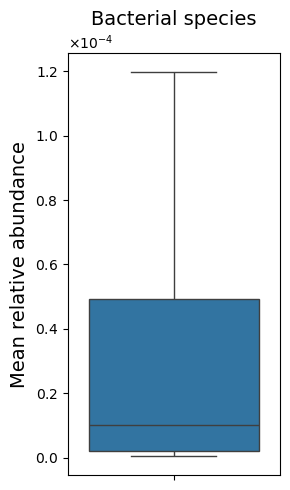

9582
1349
44
8.308408109006315e-06


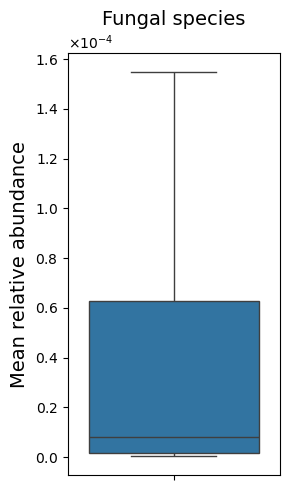

In [3]:
#图12中位数箱线图
import pandas as pd
import os
import scipy.stats as st
import numpy as np
import statsmodels.stats.multitest as smt
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
import re
import scipy.stats as stats
from statsmodels.stats.multitest import fdrcorrection
from matplotlib.ticker import ScalarFormatter
#  辅助函数：计算生态位宽度 (Bj) 
def calculate_niche_breadth_bj(relative_abundance_matrix):
    """
    计算每个 ASV 的生态位宽度 Bj。
    
    参数:
    relative_abundance_matrix (pd.DataFrame): ASV 相对丰度矩阵，
                                              索引为 ASV，列为样本。
    
    返回:
    pd.Series: 每个 ASV 的 Bj 值，索引为 ASV 名称。
    """
    relative_abundance_matrix = relative_abundance_matrix.fillna(0).astype(float)
    sum_p_ij_squared = (relative_abundance_matrix**2).sum(axis=1)
    bj_values = np.where(sum_p_ij_squared > 0, 1 / sum_p_ij_squared, np.nan)
    return pd.Series(bj_values, index=relative_abundance_matrix.index)

#  核心函数：基于 Z-score 的置换检验与分类 
def permutation_test_niche_breadth_with_zscore(relative_abundance_matrix, num_permutations=1000):
    """
    为每个 ASV 执行生态位宽度 Bj 的置换检验，并计算 Z-score 进行显著性判断。
    这是识别广适类群和专适类群的核心方法。
    
    参数:
    relative_abundance_matrix (pd.DataFrame): ASV 相对丰度矩阵，
                                              行是 ASV，列是样本。
    num_permutations (int): 置换（打乱）操作的次数。
    
    返回:
    pd.DataFrame: 包含每个 ASV 的观察 Bj 值、预期 Bj 值、零分布标准差、Z-score，
                  以及是否显著广适/专适的布尔指示列。
    """
    relative_abundance_matrix = relative_abundance_matrix.fillna(0).astype(float)
    observed_bj = calculate_niche_breadth_bj(relative_abundance_matrix)
    
    permuted_bj_list = []
    
    for _ in range(num_permutations):
        shuffled_matrix = relative_abundance_matrix.sample(frac=1, axis=1, random_state=42)
        current_perm_bj = calculate_niche_breadth_bj(shuffled_matrix)
        permuted_bj_list.append(current_perm_bj)
            
    permuted_bj_values = pd.concat(permuted_bj_list, axis=1)
    permuted_bj_values.columns = [f'perm_{i}' for i in range(num_permutations)]

    expected_bj = permuted_bj_values.mean(axis=1)
    std_dev_null_bj = permuted_bj_values.std(axis=1)
    
    results = pd.DataFrame(index=relative_abundance_matrix.index)
    results['observed_bj'] = observed_bj
    results['expected_bj'] = expected_bj
    results['std_dev_null_bj'] = std_dev_null_bj
    
    results['z_score'] = np.where(
        results['std_dev_null_bj'] > 1e-9,
        (results['observed_bj'] - results['expected_bj']) / results['std_dev_null_bj'],
        0
    )

    results['is_generalist'] = (results['z_score'] >= 2)
    results['is_specialist'] = (results['z_score'] <= -2)
    
    return results


#  细菌中位数箱线图
# 输入数据准备 (Input data prep)
# 填充颜色矩阵 (Populating color matrix)
# 根据门 (Phylum) 进行颜色编码
# 读取包含分类信息的CSV文件
metadata = pd.read_csv("/mnt/d/study/master/metadata.tsv", sep='\t')
bacteria_ASV = pd.read_csv("/mnt/d/study/master/meiji/bacteria_ASV.csv", sep=",", header=0)
# 构建要选择的列名列表，包括 "ASV" 和所有的样本ID
sample_ids = metadata['Sample ID'].tolist()
columns_to_select = ["ASV"] + sample_ids
# 从 bacteria_ASV DataFrame 中选择指定的列
b_ASV = bacteria_ASV[columns_to_select]
# 将 'ASV' 列设置为 DataFrame 的索引 (行名)
b_ASV.set_index(keys="ASV", inplace=True)
b_tax = bacteria_ASV.iloc[:, 1:9].copy()
b_tax.set_index(keys="ASV", inplace=True)
print(len(b_ASV))
# 计算 ASV 相对丰度
b_ASV_df = b_ASV.copy()

#按种
b_species = b_ASV.join(b_tax['Species'])
# 按照 'Species' 列进行分组，并对每个样本的丰度求和
b_species = b_species.groupby('Species')[sample_ids].sum()
#排序
b_species = b_species.sort_index()
b_species_df = b_species.copy()
print(len(b_species_df))
# 将当前的 ASV 索引重置为一个普通列。
b_tax_reset_index = b_tax.reset_index()
# 将 'Species' 列设置为新的索引。
b_tax_species = b_tax_reset_index.groupby('Species').first()
b_tax_species = b_tax_species.drop(columns=['ASV'])
b_tax_species = b_tax_species.sort_index()
# 进行替换操作
b_tax_species['Phylum'] = b_tax_species['Phylum'].replace('p__unclassified_k__norank_d__Bacteria', 'Unclassified')
b_tax_species['Phylum'] = b_tax_species['Phylum'].replace('p__SAR324_cladeMarine_group_B', 'SAR324')
# 去除 'p__' 前缀
b_tax_species['Phylum'] = b_tax_species['Phylum'].astype(str).str.replace("p__", "")
# 获取所有唯一的物种学名
b_unique_species_names = b_species.index.unique()
# 创建一个从物种学名到 'species_数字' 格式的映射字典
b_species_to_numeric_id = {
    species_name: f"species_{idx + 1}"
    for idx, species_name in enumerate(b_unique_species_names.sort_values()) # 先排序确保一致性
}
# 转换 b_species 的索引
b_species = b_species.rename(index= b_species_to_numeric_id)
# 转换 b_tax_species 的索引
b_tax_species = b_tax_species.rename(index= b_species_to_numeric_id)
b_species_df = b_species.copy()
print(len(b_species_df))

#核心species
# 在 Python 中，可以直接用 DataFrame 的除法功能，对列求和然后进行广播除法
b_species_rel = b_species_df.div(b_species_df.sum(axis=0), axis=1)
# 先把样本、origin 和 species 丰度组合成一个长表
# pandas 的 stack() 和 reset_index() 可以实现类似 melt 的功能
b_rel_long = b_species_rel.stack().reset_index()
b_rel_long.columns = ['species', 'Sample', 'value'] # 重命名列以匹配 R 的 melt 结果
# 创建从 Sample ID 到 Origin 和 Niche 的映射字典
sample_origins_map = metadata.set_index('Sample ID')['Origin'].to_dict()
sample_niches_map = metadata.set_index('Sample ID')['Niche'].to_dict()
# 将信息添加到长表中
b_rel_long['Origin'] = b_rel_long['Sample'].map(sample_origins_map)
b_rel_long['Niche'] = b_rel_long['Sample'].map(sample_niches_map)
b_species_total_counts = b_species.sum(axis=1) # 计算每个 species 在所有样本中的总丰度
b_total_counts_across_all_species = b_species_total_counts.sum() # 计算所有 species 的总丰度
b_species_relative_abundance = b_species_total_counts / b_total_counts_across_all_species
# 定义整体相对丰度的阈值 (0.1% 转换为小数)
overall_abundance_threshold = 0.001
# 筛选出满足整体丰度阈值的 species 名称列表
b_species_above_overall_threshold = b_species_relative_abundance[b_species_relative_abundance >= overall_abundance_threshold].index.tolist()
# 现在，只保留那些通过了整体丰度筛选的 species，用于后续的居群出现次数计算
b_rel_long_filtered_by_overall_abundance = b_rel_long[b_rel_long['species'].isin(b_species_above_overall_threshold)]
#计算 species 在每个 Origin 中是否出现 (平均丰度 > 0) 
b_species_origin_mean_filtered = b_rel_long_filtered_by_overall_abundance.groupby(['species', 'Origin'])['value'].mean().reset_index()
b_species_origin_mean_filtered.rename(columns={'value': 'mean_abundance_in_origin'}, inplace=True)
# species 在某个 Origin 中出现，如果其在该 Origin 中的平均丰度大于 0
b_species_in_origin = b_species_origin_mean_filtered[b_species_origin_mean_filtered['mean_abundance_in_origin'] > 0]
b_species_origin_count = b_species_in_origin.groupby('species')['Origin'].count().reset_index(name='origin_count')
#计算 species 在每个 Niche 中是否出现 (平均丰度 > 0) 
b_species_niche_mean_filtered = b_rel_long_filtered_by_overall_abundance.groupby(['species', 'Niche'])['value'].mean().reset_index()
b_species_niche_mean_filtered.rename(columns={'value': 'mean_abundance_in_niche'}, inplace=True)
# species 在某个 Niche 中出现，如果其在该 Niche 中的平均丰度大于 0
b_species_in_niche = b_species_niche_mean_filtered[b_species_niche_mean_filtered['mean_abundance_in_niche'] > 0]
b_species_niche_count = b_species_in_niche.groupby('species')['Niche'].count().reset_index(name='niche_count')
# 筛选核心 species 
# 合并 Origin 和 Niche 出现次数
b_species_counts_combined = pd.merge(b_species_origin_count, b_species_niche_count, on='species', how='inner')
# 定义出现次数阈值
origin_occurrence_threshold = 3
niche_occurrence_threshold = 2
# 筛选满足所有条件的 species
b_core_species_names = b_species_counts_combined[
    (b_species_counts_combined['origin_count'] >= origin_occurrence_threshold) &
    (b_species_counts_combined['niche_count'] >= niche_occurrence_threshold)
]['species'].tolist()
# 提取核心 species 的相对丰度数据
b_core_abundance = b_species_rel.loc[b_core_species_names]
b_core_species_raw_counts = b_species.loc[b_core_species_names]
print(len(b_core_species_raw_counts))

#最特殊species
#计算所有 species 整体相对丰度的中位数 
b_median_relative_abundance = b_species_relative_abundance.median()
print(b_median_relative_abundance)
# 定义稀有类群的丰度阈值 
b_rare_threshold = 0.00001

# 将 DataFrame 转换为长格式（long-format），以便 seaborn 绘制
b_species_relative_abundance_df = pd.DataFrame(b_species_relative_abundance)
b_df_long = b_species_relative_abundance_df.melt(
    var_name='Species', 
    value_name='Relative Abundance'
)
# 创建一个 figure 和 axes 对象，以便控制图表尺寸
plt.rcParams["figure.figsize"] = (3, 5)
# 使用 seaborn 绘制箱线图
ax = sns.boxplot(
    x='Species', 
    y='Relative Abundance', 
    data= b_df_long,
    showfliers=False # 不显示离群值（如果你不想显示）
)
# 获取当前的 x 轴刻度位置
current_ticks = ax.get_xticks()
# 获取当前的 x 轴标签
current_labels = ax.get_xticklabels()
# 遍历所有标签，如果标签内容是 '0'，则将其设为空字符串
for label in current_labels:
    if label.get_text() == '0':
        label.set_text('')
# 同时设置刻度位置和修改后的刻度标签
ax.set_xticks(current_ticks)
ax.set_xticklabels(current_labels)
# 保留之前的代码，以去除 x 轴标签并设置 y 轴格式
ax.set_xlabel('')
# 纵坐标使用科学计数法
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0)) # 这会强制使用科学计数法
ax.yaxis.set_major_formatter(formatter)
# 添加图表标题和坐标轴标签
plt.title('Bacterial species', size=14)
plt.ylabel('Mean relative abundance', size=14)
# 旋转x轴标签，防止重叠
plt.xticks(rotation=90)
# 保存图表为 Png 文件
plt.savefig('/mnt/d/study/master/Extended_Data_tables/Figure_12/mean_relative_bacteria.png', bbox_inches='tight', dpi=600)
# 显示图表
plt.tight_layout() # 自动调整布局，防止标签被截断
plt.show()


#  真菌中位数箱线图
# 输入数据准备 (Input data prep)
# 填充颜色矩阵 (Populating color matrix)
# 根据门 (Phylum) 进行颜色编码
# 读取包含分类信息的CSV文件
metadata = pd.read_csv("/mnt/d/study/master/metadata.tsv", sep='\t')
fungi_ASV = pd.read_csv("/mnt/d/study/master/meiji/fungi_ASV.csv", sep=",", header=0)
# 构建要选择的列名列表，包括 "ASV" 和所有的样本ID
sample_ids = metadata['Sample ID'].tolist()
columns_to_select = ["ASV"] + sample_ids
# 从 fungi_ASV DataFrame 中选择指定的列
f_ASV = fungi_ASV[columns_to_select]
# 将 'ASV' 列设置为 DataFrame 的索引 (行名)
f_ASV.set_index(keys="ASV", inplace=True)
f_tax = fungi_ASV.iloc[:, 1:9].copy()
f_tax.set_index(keys="ASV", inplace=True)
print(len(f_ASV))
# 计算 ASV 相对丰度
f_ASV_df = f_ASV.copy()

#按种
f_species = f_ASV.join(f_tax['Species'])
# 按照 'Species' 列进行分组，并对每个样本的丰度求和
f_species = f_species.groupby('Species')[sample_ids].sum()
#排序
f_species = f_species.sort_index()
# 将当前的 ASV 索引重置为一个普通列。
f_tax_reset_index = f_tax.reset_index()
# 将 'Species' 列设置为新的索引。
f_tax_species = f_tax_reset_index.groupby('Species').first()
f_tax_species = f_tax_species.drop(columns=['ASV'])
f_tax_species = f_tax_species.sort_index()
# 进行替换操作
f_tax_species['Phylum'] = f_tax_species['Phylum'].replace('p__unclassified_k__Fungi', 'Unclassified')
# 去除 'p__' 前缀
f_tax_species['Phylum'] = f_tax_species['Phylum'].astype(str).str.replace("p__", "")
# 获取所有唯一的物种学名
f_unique_species_names = f_species.index.unique()
# 创建一个从物种学名到 'species_数字' 格式的映射字典
f_species_to_numeric_id = {
    species_name: f"species_{idx + 1}"
    for idx, species_name in enumerate(f_unique_species_names.sort_values()) # 先排序确保一致性
}
# 转换 f_species 的索引
f_species = f_species.rename(index= f_species_to_numeric_id)
# 转换 f_tax_species 的索引
f_tax_species = f_tax_species.rename(index= f_species_to_numeric_id)
f_species_df = f_species.copy()
print(len(f_species_df))

#核心species
# 在 Python 中，可以直接用 DataFrame 的除法功能，对列求和然后进行广播除法
f_species_rel = f_species_df.div(f_species_df.sum(axis=0), axis=1)
# 先把样本、origin 和 species 丰度组合成一个长表
# pandas 的 stack() 和 reset_index() 可以实现类似 melt 的功能
f_rel_long = f_species_rel.stack().reset_index()
f_rel_long.columns = ['species', 'Sample', 'value'] # 重命名列以匹配 R 的 melt 结果
# 创建从 Sample ID 到 Origin 和 Niche 的映射字典
sample_origins_map = metadata.set_index('Sample ID')['Origin'].to_dict()
sample_niches_map = metadata.set_index('Sample ID')['Niche'].to_dict()
# 将信息添加到长表中
f_rel_long['Origin'] = f_rel_long['Sample'].map(sample_origins_map)
f_rel_long['Niche'] = f_rel_long['Sample'].map(sample_niches_map)
f_species_total_counts = f_species.sum(axis=1) # 计算每个 species 在所有样本中的总丰度
f_total_counts_across_all_species = f_species_total_counts.sum() # 计算所有 species 的总丰度
f_species_relative_abundance = f_species_total_counts / f_total_counts_across_all_species
# 定义整体相对丰度的阈值 (0.1% 转换为小数)
overall_abundance_threshold = 0.001
# 筛选出满足整体丰度阈值的 species 名称列表
f_species_above_overall_threshold = f_species_relative_abundance[f_species_relative_abundance >= overall_abundance_threshold].index.tolist()
# 现在，只保留那些通过了整体丰度筛选的 species，用于后续的居群出现次数计算
f_rel_long_filtered_by_overall_abundance = f_rel_long[f_rel_long['species'].isin(f_species_above_overall_threshold)]
#计算 species 在每个 Origin 中是否出现 (平均丰度 > 0) 
f_species_origin_mean_filtered = f_rel_long_filtered_by_overall_abundance.groupby(['species', 'Origin'])['value'].mean().reset_index()
f_species_origin_mean_filtered.rename(columns={'value': 'mean_abundance_in_origin'}, inplace=True)
# species 在某个 Origin 中出现，如果其在该 Origin 中的平均丰度大于 0
f_species_in_origin = f_species_origin_mean_filtered[f_species_origin_mean_filtered['mean_abundance_in_origin'] > 0]
f_species_origin_count = f_species_in_origin.groupby('species')['Origin'].count().reset_index(name='origin_count')
#计算 species 在每个 Niche 中是否出现 (平均丰度 > 0) 
f_species_niche_mean_filtered = f_rel_long_filtered_by_overall_abundance.groupby(['species', 'Niche'])['value'].mean().reset_index()
f_species_niche_mean_filtered.rename(columns={'value': 'mean_abundance_in_niche'}, inplace=True)
# species 在某个 Niche 中出现，如果其在该 Niche 中的平均丰度大于 0
f_species_in_niche = f_species_niche_mean_filtered[f_species_niche_mean_filtered['mean_abundance_in_niche'] > 0]
f_species_niche_count = f_species_in_niche.groupby('species')['Niche'].count().reset_index(name='niche_count')
# 筛选核心 species 
# 合并 Origin 和 Niche 出现次数
f_species_counts_combined = pd.merge(f_species_origin_count, f_species_niche_count, on='species', how='inner')
# 定义出现次数阈值
origin_occurrence_threshold = 3
niche_occurrence_threshold = 2
# 筛选满足所有条件的 species
f_core_species_names = f_species_counts_combined[
    (f_species_counts_combined['origin_count'] >= origin_occurrence_threshold) &
    (f_species_counts_combined['niche_count'] >= niche_occurrence_threshold)
]['species'].tolist()
# 提取核心 species 的相对丰度数据
f_core_abundance = f_species_rel.loc[f_core_species_names]
f_core_species_raw_counts = f_species.loc[f_core_species_names]
print(len(f_core_species_raw_counts))

#最特殊species
#计算所有 species 整体相对丰度的中位数 
f_median_relative_abundance = f_species_relative_abundance.median()
print(f_median_relative_abundance)
# 定义稀有类群的丰度阈值 
f_rare_threshold = 0.000008

# 将 DataFrame 转换为长格式（long-format），以便 seaborn 绘制
f_species_relative_abundance_df = pd.DataFrame(f_species_relative_abundance)
f_df_long = f_species_relative_abundance_df.melt(
    var_name='Species', 
    value_name='Relative Abundance'
)
# 创建一个 figure 和 axes 对象，以便控制图表尺寸
plt.rcParams["figure.figsize"] = (3, 5)
# 使用 seaborn 绘制箱线图
ax = sns.boxplot(
    x='Species', 
    y='Relative Abundance', 
    data= f_df_long,
    showfliers=False # 不显示离群值（如果你不想显示）
)
# 获取当前的 x 轴刻度位置
current_ticks = ax.get_xticks()
# 获取当前的 x 轴标签
current_labels = ax.get_xticklabels()
# 遍历所有标签，如果标签内容是 '0'，则将其设为空字符串
for label in current_labels:
    if label.get_text() == '0':
        label.set_text('')
# 同时设置刻度位置和修改后的刻度标签
ax.set_xticks(current_ticks)
ax.set_xticklabels(current_labels)
# 保留之前的代码，以去除 x 轴标签并设置 y 轴格式
ax.set_xlabel('')
# 纵坐标使用科学计数法
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0)) # 这会强制使用科学计数法
ax.yaxis.set_major_formatter(formatter)
# 添加图表标题和坐标轴标签
plt.title('Fungal species', size=14)
plt.ylabel('Mean relative abundance', size=14)
# 旋转x轴标签，防止重叠
plt.xticks(rotation=90)
# 保存图表为 Png 文件
plt.savefig('/mnt/d/study/master/Extended_Data_tables/Figure_12/mean_relative_fungi.png', bbox_inches='tight', dpi=600)
# 显示图表
plt.tight_layout() # 自动调整布局，防止标签被截断
plt.show()
